In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [2]:
df = pd.read_csv('heart_attack_prediction_dataset.csv')
df

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8758,MSV9918,60,Male,121,94/76,61,1,1,1,0,...,10.806373,235420,19.655895,67,7,7,Thailand,Asia,Northern Hemisphere,0
8759,QSV6764,28,Female,120,157/102,73,1,0,0,1,...,3.833038,217881,23.993866,617,4,9,Canada,North America,Northern Hemisphere,0
8760,XKA5925,47,Male,250,161/75,105,0,1,1,1,...,2.375214,36998,35.406146,527,4,4,Brazil,South America,Southern Hemisphere,1
8761,EPE6801,36,Male,178,119/67,60,1,0,1,0,...,0.029104,209943,27.294020,114,2,8,Brazil,South America,Southern Hemisphere,0


In [3]:
df.dtypes

Patient ID                             str
Age                                  int64
Sex                                    str
Cholesterol                          int64
Blood Pressure                         str
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                   str
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Country                                str
Continent  

In [4]:
df.drop(columns=['Patient ID','Country','Continent','Hemisphere'],inplace=True)

In [5]:
df.head(5)

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,Male,208,158/88,72,0,0,1,0,0,...,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,21,Male,389,165/93,98,1,1,1,1,1,...,1,0,1,4.963459,285768,27.194973,235,1,7,0
2,21,Female,324,174/99,72,1,0,0,0,0,...,1,1,9,9.463426,235282,28.176571,587,4,4,0
3,84,Male,383,163/100,73,1,1,1,0,1,...,1,0,9,7.648981,125640,36.464704,378,3,4,0
4,66,Male,318,91/88,93,1,1,1,1,0,...,1,0,6,1.514821,160555,21.809144,231,1,5,0


In [6]:
df.dtypes

Age                                  int64
Sex                                    str
Cholesterol                          int64
Blood Pressure                         str
Heart Rate                           int64
Diabetes                             int64
Family History                       int64
Smoking                              int64
Obesity                              int64
Alcohol Consumption                  int64
Exercise Hours Per Week            float64
Diet                                   str
Previous Heart Problems              int64
Medication Use                       int64
Stress Level                         int64
Sedentary Hours Per Day            float64
Income                               int64
BMI                                float64
Triglycerides                        int64
Physical Activity Days Per Week      int64
Sleep Hours Per Day                  int64
Heart Attack Risk                    int64
dtype: object

In [7]:
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Age                                0
Sex                                0
Cholesterol                        0
Blood Pressure                     0
Heart Rate                         0
Diabetes                           0
Family History                     0
Smoking                            0
Obesity                            0
Alcohol Consumption                0
Exercise Hours Per Week            0
Diet                               0
Previous Heart Problems            0
Medication Use                     0
Stress Level                       0
Sedentary Hours Per Day            0
Income                             0
BMI                                0
Triglycerides                      0
Physical Activity Days Per Week    0
Sleep Hours Per Day                0
Heart Attack Risk                  0
dtype: int64

In [10]:
df['Sex'].value_counts()

Sex
Male      6111
Female    2652
Name: count, dtype: int64

In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

In [12]:
df['Sex'].value_counts()

Sex
1    6111
0    2652
Name: count, dtype: int64

In [13]:
df.head(5)

,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,...,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
0,67,1,208,158/88,72,0,0,1,0,0,...,0,0,9,6.615001,261404,31.251233,286,0,6,0
1,21,1,389,165/93,98,1,1,1,1,1,...,1,0,1,4.963459,285768,27.194973,235,1,7,0
2,21,0,324,174/99,72,1,0,0,0,0,...,1,1,9,9.463426,235282,28.176571,587,4,4,0
3,84,1,383,163/100,73,1,1,1,0,1,...,1,0,9,7.648981,125640,36.464704,378,3,4,0
4,66,1,318,91/88,93,1,1,1,1,0,...,1,0,6,1.514821,160555,21.809144,231,1,5,0


In [14]:
df['Systolic_BP'] = df['Blood Pressure'].apply(lambda x: int(x.split('/')[0]))
df['Diastolic_BP'] = df['Blood Pressure'].apply(lambda x: int(x.split('/')[1]))

df.drop(columns='Blood Pressure',inplace=True)

In [15]:
print(df[['Systolic_BP', 'Diastolic_BP']].head())

   Systolic_BP  Diastolic_BP
0          158            88
1          165            93
2          174            99
3          163           100
4           91            88


In [16]:
df['Diet'].value_counts()

Diet
Healthy      2960
Average      2912
Unhealthy    2891
Name: count, dtype: int64

In [17]:
df['Diet'] = df['Diet'].map({'Unhealthy': 0,
                             'Average': 1,
                             'Healthy': 2})
df['Diet'].value_counts().sort_values()

Diet
0    2891
1    2912
2    2960
Name: count, dtype: int64

In [18]:
df['Heart Attack Risk'].value_counts()

Heart Attack Risk
0    5624
1    3139
Name: count, dtype: int64

In [19]:
df.head(5)

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk,Systolic_BP,Diastolic_BP
0,67,1,208,72,0,0,1,0,0,4.168189,...,9,6.615001,261404,31.251233,286,0,6,0,158,88
1,21,1,389,98,1,1,1,1,1,1.813242,...,1,4.963459,285768,27.194973,235,1,7,0,165,93
2,21,0,324,72,1,0,0,0,0,2.078353,...,9,9.463426,235282,28.176571,587,4,4,0,174,99
3,84,1,383,73,1,1,1,0,1,9.828130,...,9,7.648981,125640,36.464704,378,3,4,0,163,100
4,66,1,318,93,1,1,1,1,0,5.804299,...,6,1.514821,160555,21.809144,231,1,5,0,91,88


In [20]:
x = df.drop('Heart Attack Risk',axis=1)
y = df['Heart Attack Risk']

In [21]:
print(x.shape,y.shape)

(8763, 22) (8763,)


In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
dt = DecisionTreeClassifier(max_depth=5,criterion="gini",random_state=42,class_weight="balanced",min_samples_split=5,min_samples_leaf=2)

In [32]:
dt.fit(x_train,y_train)
y_pred = dt.predict(x_test)

In [33]:
print(f'accuracy_score:{accuracy_score(y_test,y_pred)}')
print(f'classification_report:{classification_report(y_test,y_pred)}')

accuracy_score:0.5310895607529948
classification_report:              precision    recall  f1-score   support

           0       0.63      0.65      0.64      1125
           1       0.34      0.32      0.33       628

    accuracy                           0.53      1753
   macro avg       0.48      0.49      0.48      1753
weighted avg       0.53      0.53      0.53      1753



In [34]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid.fit(x_train,y_train)

print('Best params:', grid.best_params_)
print('Best CV f1 score:', grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)

print('Test accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best params: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV f1 score: 0.4193425035441981
Test accuracy: 0.4409583571021107
              precision    recall  f1-score   support

           0       0.63      0.30      0.41      1125
           1       0.36      0.69      0.47       628

    accuracy                           0.44      1753
   macro avg       0.49      0.50      0.44      1753
weighted avg       0.53      0.44      0.43      1753



In [35]:
dt.score(x_train,y_train)

0.5796005706134094

In [36]:
dt.score(x_test,y_test)

0.5310895607529948

In [37]:
from imblearn.over_sampling import SMOTE

# SMOTE training data pe hi lagana hai, test data pe kabhi nahi
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train_sm, y_train_sm)

y_pred = model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.5704506560182544
              precision    recall  f1-score   support

           0       0.65      0.71      0.68      1125
           1       0.38      0.31      0.34       628

    accuracy                           0.57      1753
   macro avg       0.52      0.51      0.51      1753
weighted avg       0.55      0.57      0.56      1753



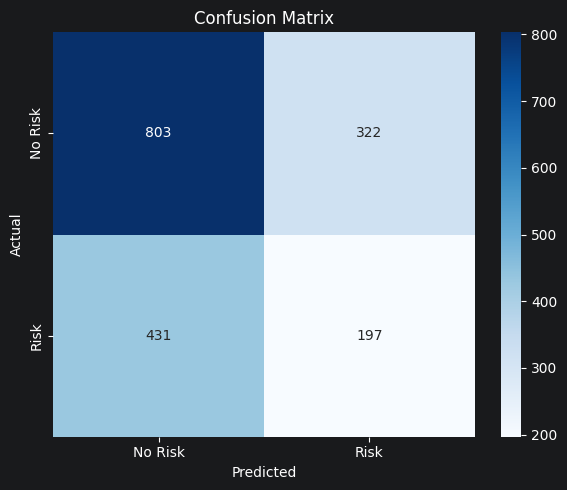

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Risk','Risk'], yticklabels=['No Risk','Risk'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

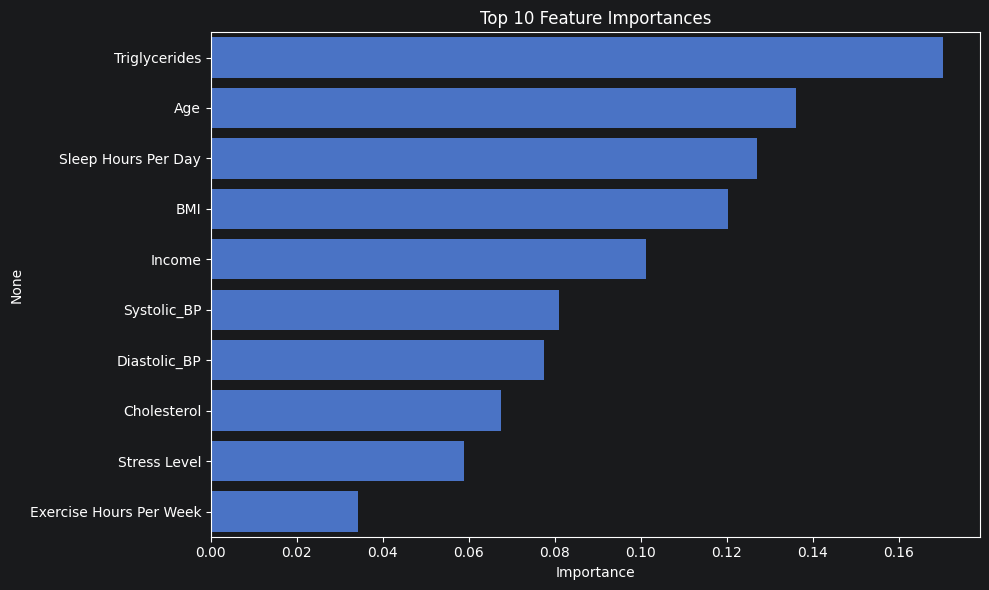

In [39]:
importances = pd.Series(dt.feature_importances_, index=x.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10])
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [40]:
import pickle

with open('dt_model.pkl', 'wb') as f:
    pickle.dump(dt, f)

In [41]:
import pickle

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

### Heart Attack Risk Prediction using Decision Tree Classifier

### 1. Objective

The goal of this project was to build a Decision Tree Classifier to predict whether a patient is at risk of a heart attack, using the Heart Attack Risk Prediction Dataset. The target variable, Heart Attack Risk, is binary (0 = No Risk, 1 = Risk).

### 2. Dataset Description

The dataset contains 8,763 patient records with 26 columns, including demographic information (Age, Sex, Country), lifestyle factors (Smoking, Alcohol Consumption, Diet, Exercise Hours), clinical measurements (Cholesterol, Blood Pressure, BMI, Triglycerides, Heart Rate), and the target label, Heart Attack Risk.

The target distribution is imbalanced, with approximately 64% of records labeled "No Risk" and 36% labeled "Risk."

### 3. Data Preprocessing

The following preprocessing steps were applied before model training:

Removed irrelevant identifiers. The Patient ID column was dropped as it carries no predictive value.

Split the Blood Pressure column. The original Blood Pressure field was stored as a string (e.g., "158/88") and was split into two separate numeric columns, Systolic_BP and Diastolic_BP.

Encoded categorical variables. Sex was label-encoded into 0/1. Diet was manually mapped to an ordinal scale (Unhealthy = 0, Average = 1, Healthy = 2) since it has a natural order.

Dropped high-cardinality geographic columns. Country, Continent, and Hemisphere were removed, as they contain many categories relative to the dataset size and risk causing the model to overfit on geography rather than learning generalizable health patterns.

After preprocessing, the dataset was split into 80% training data and 20% test data using stratified sampling, preserving the original class ratio in both sets.

### 4. Model Building

A DecisionTreeClassifier from scikit-learn was used as the base model. An initial baseline model was trained with default settings, followed by a constrained version (max_depth=5) to control overfitting.

Baseline result: Accuracy of approximately 0.64, but with a recall of only 0.01 for the "Risk" class — indicating the model was essentially predicting the majority class ("No Risk") for almost every sample, despite the seemingly high accuracy.

### 5. Handling Class Imbalance

Since accuracy alone was misleading on this imbalanced dataset, two techniques were tested to improve detection of the minority "Risk" class:

Class weighting (class_weight='balanced'): Penalizes misclassification of the minority class more heavily during training. This reduced overall accuracy to ~0.44 but increased recall for the "Risk" class to ~0.69, meaning the model correctly identified far more at-risk patients, at the cost of more false positives.

SMOTE (Synthetic Minority Oversampling): Generated synthetic samples of the minority class in the training set only, balancing the class distribution before training. This improved overall accuracy to ~0.52–0.57, but with lower recall (~0.31–0.36) for the "Risk" class compared to class weighting.

These results highlight a precision-recall trade-off: class weighting favors catching more true risk cases at the cost of more false alarms, while SMOTE favors overall accuracy but misses more true risk cases.

### 6. Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation was used to tune max_depth, min_samples_split, min_samples_leaf, and class_weight, optimizing for F1-score (rather than accuracy) due to the class imbalance. The best configuration found was max_depth=3, min_samples_split=2, min_samples_leaf=1, class_weight='balanced', achieving a cross-validated F1-score of approximately 0.42.

### 7. Feature Engineering

Two derived features were created to test whether categorizing clinical measurements would help the model: BP_Category (Normal / Elevated / High Stage 1 / High Stage 2, based on standard medical thresholds) and BMI_Category (Underweight / Normal / Overweight / Obese).

Adding these features produced no measurable change in model performance (identical F1-score to the model without them). This suggests the decision tree was already extracting the relevant threshold information directly from the raw Systolic_BP, Diastolic_BP, and BMI columns, so the categorical versions added no new information.

### 8. Feature Importance and Confusion Matrix

A feature importance plot and a confusion matrix heatmap were generated to better interpret the final tuned model.

Feature importance. The most influential features were Triglycerides, Age, Sleep Hours Per Day, BMI, and Income. As in earlier runs, the presence of Income among the top features is unexpected for a medical risk model and is itself a sign of weak, possibly spurious, signal in the dataset rather than a genuine clinical relationship.

Confusion matrix. The heatmap showed that a substantial number of true "Risk" cases were misclassified as "No Risk" (roughly 425 out of 628 in one test split), which is the direct cause of the model's low recall for the minority class. This visualization makes the precision-recall trade-off discussed earlier (Section 5) easier to see at a glance, since it shows exactly where the model's errors are concentrated rather than only summarizing them as a single recall number.

### 9. Key Finding

Across all techniques tested (class weighting, SMOTE, hyperparameter tuning, and feature engineering), the model's performance remained in a similar range (F1-score roughly 0.34–0.47), well below what would be expected for a dataset with a genuinely strong relationship between features and outcome. This indicates that the dataset itself has a weak underlying relationship between the available features and the heart attack risk label, which is a known characteristic of this dataset (it does not reflect a true clinical/diagnostic signal). Consequently, no single technique was able to dramatically outperform the others — the ceiling on achievable performance appears to be limited by the data itself rather than by model choice or tuning.

### 10. Conclusion

A Decision Tree Classifier was successfully built, tuned, and evaluated on the Heart Attack Risk Prediction Dataset. While various techniques (class weighting, SMOTE, hyperparameter tuning, feature engineering) were applied to address class imbalance and improve performance, results remained modest, with F1-scores for the minority class in the 0.34–0.47 range. This was traced to weak inherent correlation between the dataset's features and the target label, rather than a deficiency in modeling approach. This exercise underscores the importance of evaluating model performance using metrics beyond accuracy (such as precision, recall, and F1-score) when working with imbalanced classification problems, and of critically assessing whether a dataset contains a learnable signal before drawing conclusions from model accuracy alone.

### 11. Possible Future Improvements

Future work could explore ensemble methods such as Random Forest or Gradient Boosting, which typically generalize better than a single decision tree; probability threshold tuning instead of the default 0.5 cutoff; or, most importantly, validating findings against a real-world clinical dataset to confirm whether the weak signal is specific to this synthetic dataset.